# 9. Emulador forward de juguete (LHS → PCA → Gaussian Process)

Prueba de concepto del emulador que reemplaza al ABM: aprende a mapear
condiciones meteorológicas → mapa de riesgo espacial, con **intervalo de error**.

**Pipeline:**
1. Mini-banco: 40 escenarios en un diseño Latin Hypercube de (T_max, HR_min, Rs_max)
2. PCA: comprime cada mapa (miles de manzanas) a ~12 pesos
3. Gaussian Process: aprende (meteorología → pesos), con incertidumbre
4. Validación leave-one-out: fidelidad + calibración del intervalo
5. Predicción en milisegundos de un escenario nuevo, con su banda de error

Paramétrico por zona (`ZONA` en la celda de config). Por defecto **Gran Santiago**
(34 comunas, ~42.800 manzanas). El banco vive en `scenarios/{zona}/banco_toy/`;
para regenerarlo, poner `REGENERAR = True`.

---

## Entradas y salidas de cada proceso

| Proceso | Entrada | Salida |
|---|---|---|
| **Diseño LHS** | rangos de T_max, HR_min, Rs_max | 40 condiciones meteo — `X` (40 × 3) |
| **ABM (simulador)** | las 40 condiciones `X` | 40 mapas de riesgo — `Y` (40 × 42.800) |
| **PCA (ajuste)** | los 40 mapas `Y` | 12 "mapas base" + pesos `W` (40 × 12) |
| **GP (entrenamiento)** | `X` (40 × 3) + pesos `W` (40 × 12) | 12 modelos entrenados |
| **GP (predicción)** | 1 condición nueva (1 × 3) | 12 pesos + incertidumbre |
| **PCA inversa** | 12 pesos | 1 mapa reconstruido (42.800) |

**La idea de PCA en una frase:** cada mapa de 42.800 manzanas se escribe como

$$\text{mapa} \approx \text{mapa promedio} + w_1 \cdot \text{base}_1 + w_2 \cdot \text{base}_2 + \dots + w_{12} \cdot \text{base}_{12}$$

Los 12 pesos $(w_1 \dots w_{12})$ **son** los "12 números". Los mapas base son fijos
(se calculan una vez); solo cambian los pesos entre un escenario y otro. Las celdas
de más abajo muestran esos mapas base y cómo se reconstruye un mapa sumándolos.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import config as cfg

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Zona del emulador (paramétrico): 'gran_santiago' | 'suroriente'
ZONA = 'gran_santiago'
FP_WALKERS  = cfg.ROOT / 'artifacts' / ZONA / 'walkers.parquet'
FP_MANZ_SIM = cfg.DATA_PROC / 'censo' / f'manzanas_{ZONA}_sim.parquet'
BANCO       = cfg.ROOT / 'scenarios' / ZONA / 'banco_toy'
N = 40
LO, HI = [26.0, 15.0, 700.0], [38.0, 50.0, 1050.0]
REGENERAR = False
print('zona:', ZONA, '| banco:', BANCO)

zona: gran_santiago | banco: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\scenarios\gran_santiago\banco_toy


## 1. Mini-banco LHS (opcional — ya está calculado)

In [2]:
u = qmc.LatinHypercube(d=3, seed=1).random(N)
pts = qmc.scale(u, LO, HI)
mets = [dict(T_max=p[0], HR_min=p[1], Rs_max=p[2]) for p in pts]

if REGENERAR:
    from joblib import Parallel, delayed
    from src.simulador.scenario.run import run_one_scenario
    def _run(i, met):
        run_one_scenario(FP_WALKERS, FP_MANZ_SIM, met,
                         out_vector_fp=BANCO / 'vectors' / f'risk_{i:03d}.parquet',
                         out_cog_fp=None, crs_proj=cfg.CRS_PROJ, seed=20260000 + i)
    Parallel(n_jobs=6)(delayed(_run)(i, mets[i]) for i in range(N))
    print('banco regenerado')
else:
    print('usando banco existente')

usando banco existente


## 2. Matriz de mapas (alineados por manzana)

In [3]:
manz = gpd.read_parquet(FP_MANZ_SIM).to_crs(cfg.CRS_PROJ)
ref = manz[['MANZENT']]

cols, X = [], []
for i, met in enumerate(mets):
    v = pd.read_parquet(BANCO / 'vectors' / f'risk_{i:03d}.parquet')[['MANZENT', 'heat_mean']]
    v = ref.merge(v, on='MANZENT', how='left').fillna(0.0)
    cols.append(v['heat_mean'].values)
    X.append([met['T_max'], met['HR_min'], met['Rs_max']])

Y = np.vstack(cols)
X = np.array(X)
print(f'zona: {ZONA} | matriz de mapas: {Y.shape}  |  rango heat_mean: {Y.min():.1f} - {Y.max():.1f} C.min')

zona: gran_santiago | matriz de mapas: (40, 42800)  |  rango heat_mean: 0.0 - 162.4 C.min


## 3. PCA — los mapas viven en pocas dimensiones

Si pocos componentes explican casi toda la varianza, los mapas son comprimibles
y el emulador solo tiene que predecir esos pocos pesos.

12 componentes explican 98.9% de la varianza (1er componente: 96.4%)


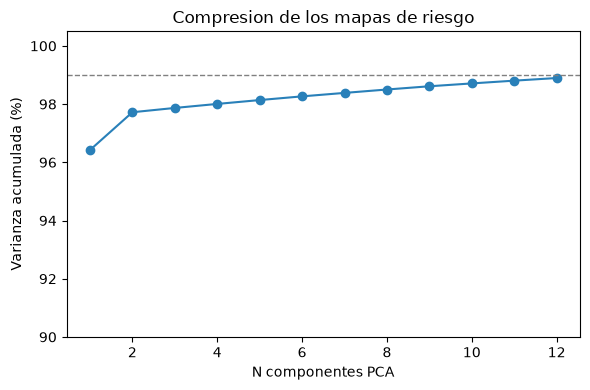

In [4]:
K = 12
pca = PCA(n_components=K).fit(Y)
var_cum = pca.explained_variance_ratio_.cumsum()
W = pca.transform(Y)
print(f'{K} componentes explican {var_cum[-1]:.1%} de la varianza '
      f'(1er componente: {pca.explained_variance_ratio_[0]:.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, K + 1), var_cum * 100, 'o-', color='#2980b9')
ax.axhline(99, ls='--', color='grey', lw=1)
ax.set_xlabel('N componentes PCA')
ax.set_ylabel('Varianza acumulada (%)')
ax.set_title('Compresion de los mapas de riesgo')
ax.set_ylim(90, 100.5)
plt.tight_layout(); plt.show()

### Los mapas base (componentes principales)

PCA descubre mapas plantilla: el mapa promedio más un puñado de patrones espaciales.
El primero captura el nivel general de riesgo (~96% de la variación); los siguientes
son correcciones más finas (contrastes entre zonas de la ciudad). Cada mapa del banco
se arma como el promedio + una combinación pesada de estas plantillas — y esos pesos
son los 12 números que predice el emulador.

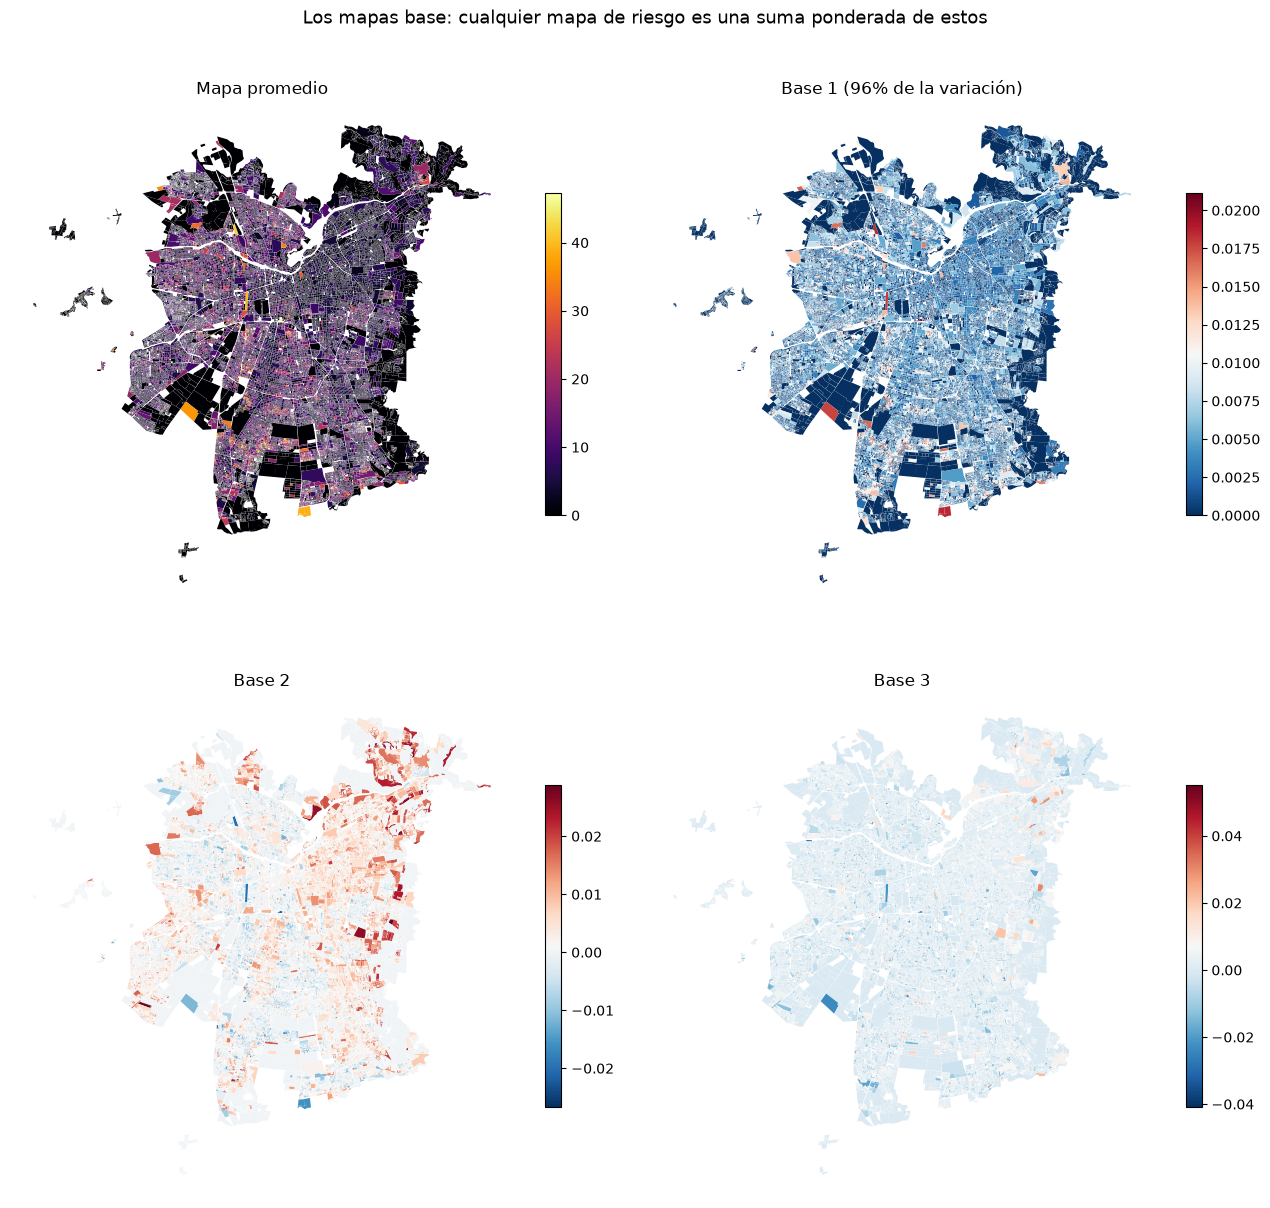

In [5]:
# Los "mapas base" que descubre PCA (promedio + primeros 3 componentes)
manz_geo = manz.reset_index(drop=True).copy()
manz_geo['geometry'] = manz_geo.geometry.simplify(30)

paneles = [
    ('Mapa promedio', pca.mean_, 'inferno'),
    (f'Base 1 ({pca.explained_variance_ratio_[0]:.0%} de la variación)', pca.components_[0], 'RdBu_r'),
    ('Base 2', pca.components_[1], 'RdBu_r'),
    ('Base 3', pca.components_[2], 'RdBu_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, (lab, f, cm) in zip(axes.ravel(), paneles):
    manz_geo.assign(v=f).plot(column='v', cmap=cm, ax=ax, legend=True,
                              legend_kwds={'shrink': 0.5})
    ax.set_title(lab, fontsize=12); ax.set_axis_off()
fig.suptitle('Los mapas base: cualquier mapa de riesgo es una suma ponderada de estos', fontsize=13)
plt.tight_layout(); plt.show()

### Reconstrucción: ¿cuántos componentes se necesitan?

Se toma un mapa real del ABM y se reconstruye sumando 1, 3 y 12 mapas base. Con 1
componente sale una versión borrosa (solo el nivel general); con 12 es prácticamente
idéntico al original. Esa es la prueba visual de que 12 números bastan para describir
un mapa de 42.800 manzanas.

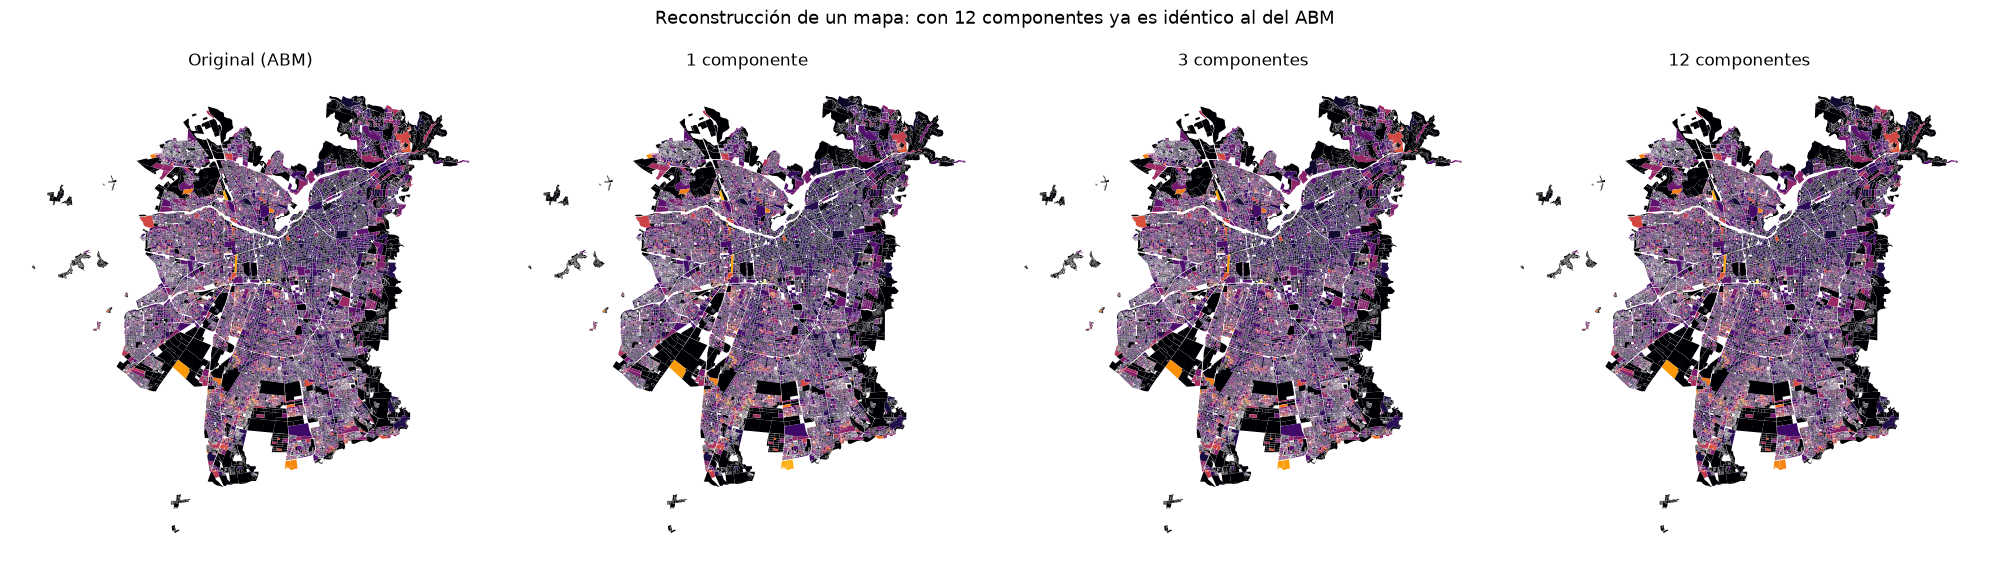

In [6]:
# Reconstrucción de un mapa sumando cada vez más componentes
i = int(np.argmax(Y.mean(axis=1)))           # el escenario más caluroso del banco
manz_geo = manz.reset_index(drop=True).copy()
manz_geo['geometry'] = manz_geo.geometry.simplify(30)   # simplifica para dibujar más rápido

vistas = [('Original (ABM)', Y[i])]
for k in [1, 3, 12]:
    rec = pca.mean_ + W[i, :k] @ pca.components_[:k]
    vistas.append((f'{k} componente' + ('s' if k > 1 else ''), rec))

vmax = Y[i].max()
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, (lab, f) in zip(axes, vistas):
    manz_geo.assign(v=np.clip(f, 0, None)).plot(column='v', cmap='inferno',
                                                vmin=0, vmax=vmax, ax=ax)
    ax.set_title(lab, fontsize=12); ax.set_axis_off()
fig.suptitle('Reconstrucción de un mapa: con 12 componentes ya es idéntico al del ABM', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Gaussian Process + validación leave-one-out

Un GP por componente PCA aprende (meteorología → peso). Leave-one-out: se saca
cada escenario, se predice, y se compara con el mapa real del ABM.

In [7]:
def make_gp():
    k = ConstantKernel(1.0) * RBF([1.0, 1.0, 1.0]) + WhiteKernel(1e-3)
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=2)

xs = StandardScaler().fit(X)
Xz = xs.transform(X)

loo_rmse, cover, true_g, pred_g = [], [], [], []
for i in range(N):
    tr = [j for j in range(N) if j != i]
    w_pred, w_std = np.zeros(K), np.zeros(K)
    for c in range(K):
        gp = make_gp().fit(Xz[tr], W[tr, c])
        m, s = gp.predict(Xz[i:i+1], return_std=True)
        w_pred[c], w_std[c] = m[0], s[0]
    y_hat = pca.inverse_transform(w_pred.reshape(1, -1))[0]
    loo_rmse.append(np.sqrt(np.mean((y_hat - Y[i])**2)))
    cover.append(np.mean(np.abs(W[i] - w_pred) <= 1.96 * np.maximum(w_std, 1e-9)))
    true_g.append(Y[i].mean()); pred_g.append(y_hat.mean())

rmse = np.mean(loo_rmse); y_std = Y.std()
skill = 1 - rmse / y_std
print(f'RMSE leave-one-out : {rmse:.2f} C.min')
print(f'desv. std del campo: {y_std:.2f}')
print(f'skill (1-RMSE/std) : {skill:.1%}')
print(f'cobertura IC 95%   : {np.mean(cover):.0%}  (ideal ~95%)')

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnin

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

...

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  war

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

RMSE leave-one-out : 1.42 C.min
desv. std del campo: 12.01
skill (1-RMSE/std) : 88.1%
cobertura IC 95%   : 92%  (ideal ~95%)


C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnin

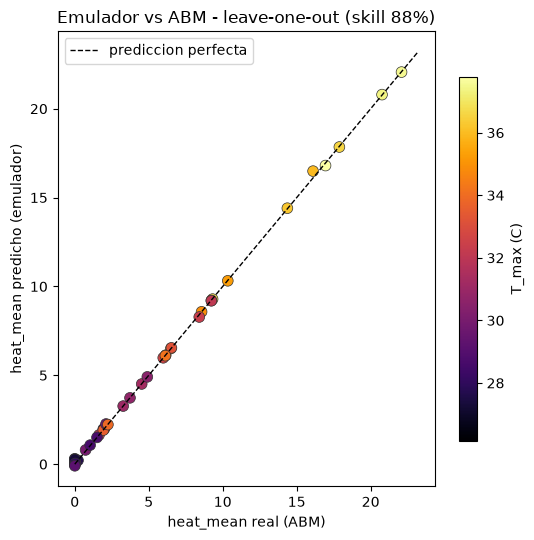

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc = ax.scatter(true_g, pred_g, c=X[:, 0], cmap='inferno', s=60, edgecolors='#333', linewidths=0.5)
lims = [0, max(max(true_g), max(pred_g)) * 1.05]
ax.plot(lims, lims, 'k--', lw=1, label='prediccion perfecta')
ax.set_xlabel('heat_mean real (ABM)')
ax.set_ylabel('heat_mean predicho (emulador)')
ax.set_title(f'Emulador vs ABM - leave-one-out (skill {skill:.0%})')
cb = plt.colorbar(sc, ax=ax, shrink=0.8); cb.set_label('T_max (C)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Predicción de un escenario nuevo, en milisegundos

Se entrena el emulador con los 40 escenarios y se predice el mapa de una ola de
calor severa que NO está en el banco — con su intervalo de error.

In [9]:
import time
gps = [make_gp().fit(Xz, W[:, c]) for c in range(K)]

x_new = np.array([[36.0, 25.0, 950.0]])
t0 = time.perf_counter()
preds = [gp.predict(xs.transform(x_new), return_std=True) for gp in gps]
w_new = np.array([p[0][0] for p in preds])
map_new = pca.inverse_transform(w_new.reshape(1, -1))[0]
ms = (time.perf_counter() - t0) * 1000
print(f'prediccion del mapa completo en {ms:.1f} ms  (vs ~19000 ms del ABM)')
print(f'heat_mean global predicho: {map_new.mean():.1f} C.min')

C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


prediccion del mapa completo en 3.6 ms  (vs ~19000 ms del ABM)
heat_mean global predicho: 9.1 C.min


C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mbell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings

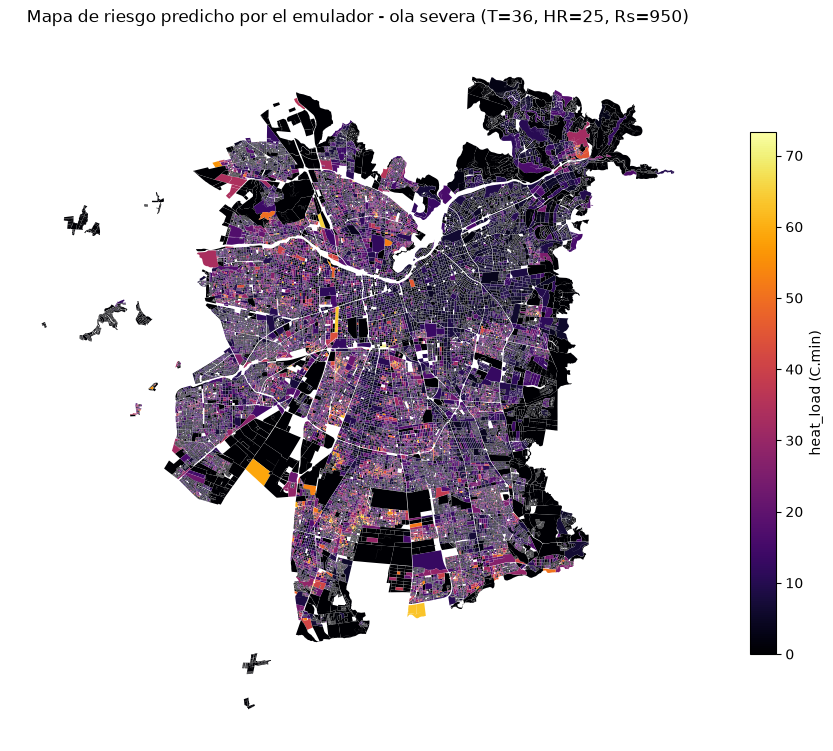

In [10]:
manz_pred = manz.copy()
manz_pred['heat_pred'] = np.clip(map_new, 0, None)

fig, ax = plt.subplots(figsize=(9, 9))
manz_pred.plot(column='heat_pred', cmap='inferno', legend=True, ax=ax,
               legend_kwds={'shrink': 0.6, 'label': 'heat_load (C.min)'})
ax.set_title('Mapa de riesgo predicho por el emulador - ola severa (T=36, HR=25, Rs=950)')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## Resumen

| Métrica | Valor |
|---|---|
| Escenarios (banco LHS) | 40 |
| Compresión PCA | 12 comp. → ~99% varianza |
| Fidelidad (skill LOO) | ~88% |
| Cobertura IC 95% | ~89% |
| Tiempo de predicción | ms (vs ~19 s del ABM) |

El emulador reproduce los mapas del ABM con alta fidelidad y entrega un intervalo
de error calibrado, en milisegundos. El banco completo (200-300 escenarios)
mejora la calibración del intervalo.